# Inferencia y Analisis Thoracolumbar Explicado - Colab

Este notebook corresponde a la etapa de **inferencia, visualizacion y analisis de errores**
del modelo thoracolumbar.

## Objetivo

Usar el mejor modelo multiclase entrenado para:

1. generar predicciones sobre el conjunto de test
2. visualizar la ROI, la mascara real y la mascara predicha
3. estudiar errores tipicos por vertebra
4. extraer componentes conectados y centroides por clase
5. dejar tablas exportables para el documento de decisiones del proyecto

## Por que este notebook es importante

Hasta este punto ya vimos que el entrenamiento mejora, pero las metricas por si solas
no nos dicen **como** falla el modelo. Este notebook busca responder preguntas como:

- si la ROI realmente cubre bien la columna
- si el modelo omite vertebras concretas
- si fusiona vertebras vecinas
- si confunde niveles toracicos intermedios
- si los centroides anatomicos predichos siguen un orden razonable

## 0. Preparacion de Colab

Esta celda monta Google Drive y ubica el notebook en la carpeta del proyecto.

Antes de correrla:

1. asegúrate de tener el proyecto completo en Google Drive
2. ajusta `PROJECT_ROOT` si tu ruta en Drive es distinta

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"No existe la carpeta: {PROJECT_ROOT}")

os.chdir(PROJECT_ROOT)
print("Working directory:", Path.cwd())


Mounted at /content/drive
Working directory: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work


## 1. Librerias, configuracion y archivos requeridos

En esta celda definimos:

- rutas de entrada
- el checkpoint multiclase que vamos a analizar
- la configuracion de inferencia
- el directorio de exportacion de resultados

Por defecto usamos el modelo experimental mas fuerte que construimos hasta ahora:
`thoracolumbar_partial_cascade_explained_tuned_best.pt`

In [2]:
from __future__ import annotations

import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage as ndi

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd()
DATASET_ROOT = Path("/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/data/ScoliosisDataSetYeisson")

def resolve_existing(*relative_candidates: str) -> Path:
    search_roots = [ROOT, ROOT / 'data' / 'ScoliosisDataSetYeisson', ROOT / 'data', ROOT / 'reports']
    for base in search_roots:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'No se encontro ninguno de estos archivos: {relative_candidates}')


INDEX_PATH = resolve_existing('indice_dataset.csv')
DICT_PATH = resolve_existing('diccionario_etiquetas_T1_T12_L1_L5.json')
MANIFEST_PATH = resolve_existing('analysis_outputs/training_manifest_thoracolumbar.csv')
BINARY_GROUP_MAP_PATH = resolve_existing('analysis_outputs/training_runs_binary_thoracolumbar/binary_spine_group_partition_map.csv')
BINARY_MODEL_PATH = resolve_existing('models/binary_spine_thoracolumbar_best.pt')
MULTICLASS_MODEL_PATH = resolve_existing('models/thoracolumbar_partial_cascade_explained_tuned_best.pt')
OUTPUT_DIR = ROOT / 'analysis_outputs' / 'thoracolumbar_inference_analysis_explained_tuned'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in [INDEX_PATH, DICT_PATH, MANIFEST_PATH, BINARY_GROUP_MAP_PATH, BINARY_MODEL_PATH, MULTICLASS_MODEL_PATH]:
    if not path.exists():
        raise FileNotFoundError(f'No existe archivo requerido: {path}')

def resolve_dataset_path(rel: str) -> str:
    rel_path = Path(str(rel).replace(chr(92), '/'))
    if rel_path.is_absolute():
        return str(rel_path)
    candidates = [
        ROOT / rel_path,
        DATASET_ROOT / rel_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate.resolve())
    return str((DATASET_ROOT / rel_path).resolve())

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE_BINARY = (512, 256)
IMG_SIZE_MULTICLASS = (640, 320)
IGNORE_INDEX = 255
BINARY_THRESHOLD = 0.50
ROI_PAD_X = 28
ROI_PAD_Y = 44
MIN_FOREGROUND_PIXELS = 24
MIN_COMPONENT_PIXELS = 30
N_VIS_SAMPLES = 6
TARGET_SUBSET = 'partial'

print('DEVICE:', DEVICE)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('MULTICLASS_MODEL_PATH:', MULTICLASS_MODEL_PATH)


DEVICE: cuda
OUTPUT_DIR: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/thoracolumbar_inference_analysis_explained_tuned
MULTICLASS_MODEL_PATH: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/models/thoracolumbar_partial_cascade_explained_tuned_best.pt


## 2. Carga de metadata y seleccion del conjunto de test

Esta celda reconstruye el mismo subconjunto usado en entrenamiento para mantener
consistencia metodologica.

Seleccionamos:

- el subset `partial`
- solo la particion `test`

Asi el analisis queda centrado en las predicciones sobre datos no vistos.

In [3]:
index_df_raw = pd.read_csv(INDEX_PATH)
manifest_df = pd.read_csv(MANIFEST_PATH)
group_map_df = pd.read_csv(BINARY_GROUP_MAP_PATH)
with open(DICT_PATH, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

index_col_map = {
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
    'ruta_mascara_multiclase_id_png': 'multiclass_id_png',
}
index_df = index_df_raw.rename(columns=index_col_map).copy()

final_multiclass_map = {int(k): v for k, v in labels_dict['mascara_multiclase_id_png'].items()}
class_names = [final_multiclass_map[i] for i in range(len(final_multiclass_map))]
num_classes = len(class_names)
valid_multiclass_ids = set(range(num_classes))
foreground_class_ids = [i for i in range(1, num_classes)]

join_cols = ['split', 'image', 'patient_id', 'radiograph_path']
dataset_subset = index_df[join_cols + ['label_binary_path', 'multiclass_id_png']].copy()
table = manifest_df.merge(dataset_subset, on=join_cols, how='left', suffixes=('', '_idx'))
table['multiclass_mask_path'] = table['mask_path'].fillna(table['multiclass_id_png'])
table['radiograph_path_abs'] = table['radiograph_path'].apply(resolve_dataset_path)
table['binary_mask_path_abs'] = table['label_binary_path'].apply(resolve_dataset_path)
table['multiclass_mask_path_abs'] = table['multiclass_mask_path'].apply(resolve_dataset_path)

for col in ['usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial', 'needs_annotation_review']:
    if col in table.columns:
        table[col] = table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == 'true'
        )

group_partition_map = group_map_df.drop_duplicates().set_index('group_id_for_split')['partition'].to_dict()
table['partition'] = table['group_id_for_split'].map(group_partition_map)

subset_flag = 'usable_for_thoracolumbar_core' if TARGET_SUBSET == 'core' else 'usable_for_thoracolumbar_partial'
analysis_df = table.loc[
    table[subset_flag] & ~table['needs_annotation_review'] & table['partition'].eq('test')
].copy().reset_index(drop=True)

print('Subset analizado:', TARGET_SUBSET)
print('Muestras de test:', len(analysis_df))
display(analysis_df.groupby('split').size().rename('images').reset_index())
display(analysis_df.head())

Subset analizado: partial
Muestras de test: 45


,split,images
0,Normal,17
1,Scoliosis,28


,split,image,patient_id,radiograph_path,mask_path,num_visible_target_vertebrae,first_visible_target,last_visible_target,visible_target_span_signature,present_target_vertebrae,...,usable_for_thoracolumbar_core,usable_for_thoracolumbar_partial,needs_annotation_review,usable_for_cobb_regression,label_binary_path,multiclass_id_png,multiclass_mask_path,binary_mask_path_abs,multiclass_mask_path_abs,partition
0,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,True,True,False,False,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,/content/drive/Othercomputers/Mi portátil/Scol...,/content/drive/Othercomputers/Mi portátil/Scol...,test
1,Normal,N_6.jpg,6,Normal/N_6.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_6.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,True,True,False,False,LabelBinaryJPG/Label_N_6.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_6.png,LabelMultiClass_ID_PNG/LabelMulti_N_6.png,/content/drive/Othercomputers/Mi portátil/Scol...,/content/drive/Othercomputers/Mi portátil/Scol...,test
2,Normal,N_8.jpg,8,Normal/N_8.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_8.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,True,True,False,False,LabelBinaryJPG/Label_N_8.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_8.png,LabelMultiClass_ID_PNG/LabelMulti_N_8.png,/content/drive/Othercomputers/Mi portátil/Scol...,/content/drive/Othercomputers/Mi portátil/Scol...,test
3,Normal,N_15.jpg,15,Normal/N_15.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_15.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,True,True,False,False,LabelBinaryJPG/Label_N_15.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_15.png,LabelMultiClass_ID_PNG/LabelMulti_N_15.png,/content/drive/Othercomputers/Mi portátil/Scol...,/content/drive/Othercomputers/Mi portátil/Scol...,test
4,Normal,N_18.jpg,18,Normal/N_18.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_18.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,True,True,False,False,LabelBinaryJPG/Label_N_18.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_18.png,LabelMultiClass_ID_PNG/LabelMulti_N_18.png,/content/drive/Othercomputers/Mi portátil/Scol...,/content/drive/Othercomputers/Mi portátil/Scol...,test


## 3. Utilidades de imagen, ROI y preprocesamiento

Esta celda reimplementa el pipeline de inferencia para que el notebook sea
autocontenido.

Puntos clave:

- el binario localiza la columna
- la ROI se expande con padding
- la imagen se normaliza
- se agregan canales de coordenadas `y` y `x`

In [4]:
def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert('L'))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR))


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((size[1], size[0]), resample=Image.NEAREST))


def build_binary_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    if size is not None:
        mask = resize_mask(mask, size)
    return mask


def build_multiclass_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    raw = np.array(Image.open(path), dtype=np.int32)
    out = np.zeros_like(raw, dtype=np.uint8)
    valid_mask = np.isin(raw, list(valid_multiclass_ids))
    out[~valid_mask] = IGNORE_INDEX
    out[valid_mask] = raw[valid_mask].astype(np.uint8)
    if size is not None:
        out = resize_mask(out, size)
    return out


def bbox_from_mask(mask: np.ndarray, min_foreground_pixels: int = 24) -> tuple[int, int, int, int] | None:
    ys, xs = np.where(mask > 0)
    if len(xs) < min_foreground_pixels:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1


def clamp_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    h, w = image_shape
    x0, y0, x1, y1 = bbox
    x0 = max(0, min(x0, w - 1))
    y0 = max(0, min(y0, h - 1))
    x1 = max(x0 + 1, min(x1, w))
    y1 = max(y0 + 1, min(y1, h))
    return x0, y0, x1, y1


def expand_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int], pad_x: int = 28, pad_y: int = 44) -> tuple[int, int, int, int]:
    x0, y0, x1, y1 = bbox
    return clamp_bbox((x0 - pad_x, y0 - pad_y, x1 + pad_x, y1 + pad_y), image_shape)


def scale_bbox(bbox: tuple[int, int, int, int], src_shape: tuple[int, int], dst_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    src_h, src_w = src_shape
    dst_h, dst_w = dst_shape
    x0, y0, x1, y1 = bbox
    sx = dst_w / src_w
    sy = dst_h / src_h
    scaled = (int(round(x0 * sx)), int(round(y0 * sy)), int(round(x1 * sx)), int(round(y1 * sy)))
    return clamp_bbox(scaled, dst_shape)


def full_image_bbox(image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    h, w = image_shape
    return 0, 0, w, h


def crop_array(arr: np.ndarray, bbox: tuple[int, int, int, int]) -> np.ndarray:
    x0, y0, x1, y1 = bbox
    return arr[y0:y1, x0:x1]


def normalize_image(image_2d: np.ndarray) -> np.ndarray:
    mean = float(image_2d.mean())
    std = float(image_2d.std())
    if std < 1e-6:
        return image_2d - mean
    return (image_2d - mean) / std


def build_coordinate_channels(height: int, width: int) -> np.ndarray:
    y_coords = np.linspace(0.0, 1.0, height, dtype=np.float32)[:, None]
    x_coords = np.linspace(0.0, 1.0, width, dtype=np.float32)[None, :]
    y_map = np.repeat(y_coords, width, axis=1)
    x_map = np.repeat(x_coords, height, axis=0)
    return np.stack([y_map, x_map], axis=0)


def build_roi_record_from_binary_mask(binary_mask: np.ndarray, image_shape: tuple[int, int], roi_source: str) -> dict:
    bbox = bbox_from_mask(binary_mask, min_foreground_pixels=MIN_FOREGROUND_PIXELS)
    if bbox is None:
        bbox = full_image_bbox(image_shape)
        roi_source = f'{roi_source}_fallback_full_image'
    else:
        bbox = expand_bbox(bbox, image_shape=image_shape, pad_x=ROI_PAD_X, pad_y=ROI_PAD_Y)
    x0, y0, x1, y1 = bbox
    return {
        'bbox_x0': x0,
        'bbox_y0': y0,
        'bbox_x1': x1,
        'bbox_y1': y1,
        'bbox_width': x1 - x0,
        'bbox_height': y1 - y0,
        'roi_source': roi_source,
    }

## 4. Definicion de modelos

Necesitamos dos modelos:

- el binario para localizar la columna
- el multiclase para identificar vertebras

Ambas arquitecturas se reconstruyen exactamente como en sus respectivos notebooks
de entrenamiento para que los checkpoints carguen correctamente.

In [5]:
class DoubleConvBinary(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class BinaryUNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConvBinary(in_channels, base)
        self.e2 = DoubleConvBinary(base, base * 2)
        self.e3 = DoubleConvBinary(base * 2, base * 4)
        self.e4 = DoubleConvBinary(base * 4, base * 8)
        self.b = DoubleConvBinary(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConvBinary(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConvBinary(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConvBinary(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConvBinary(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)


class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetEnhanced(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 48, dropout: float = 0.10):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base, dropout=0.0)
        self.e2 = DoubleConv(base, base * 2, dropout=0.0)
        self.e3 = DoubleConv(base * 2, base * 4, dropout=0.0)
        self.e4 = DoubleConv(base * 4, base * 8, dropout=dropout * 0.5)
        self.b = DoubleConv(base * 8, base * 16, dropout=dropout)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8, dropout=dropout * 0.5)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4, dropout=0.0)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2, dropout=0.0)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base, dropout=0.0)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)

## 5. Inferencia binaria, ROI y preparacion de entrada multiclase

Esta celda ejecuta el modelo binario sobre cada imagen del conjunto de test.

Salidas de interes:

- bounding box de la ROI
- fuente de la ROI (`pred_binary` o fallback)
- tensor listo para la red multiclase

In [6]:
binary_model = BinaryUNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_model.load_state_dict(torch.load(BINARY_MODEL_PATH, map_location=DEVICE))
binary_model.eval()

multiclass_model = UNetEnhanced(in_channels=3, out_channels=num_classes, base=48, dropout=0.10).to(DEVICE)
multiclass_model.load_state_dict(torch.load(MULTICLASS_MODEL_PATH, map_location=DEVICE))
multiclass_model.eval()


def predict_binary_roi_for_row(row: pd.Series) -> dict:
    image_raw = read_gray(row['radiograph_path_abs'])
    original_shape = image_raw.shape
    image_resized = resize_image(image_raw, IMG_SIZE_BINARY).astype(np.float32) / 255.0
    image_tensor = torch.tensor(image_resized[None, None, ...], dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        logits = binary_model(image_tensor)
        pred_mask_small = (torch.sigmoid(logits)[0, 0].detach().cpu().numpy() >= BINARY_THRESHOLD).astype(np.uint8)

    bbox_small = bbox_from_mask(pred_mask_small, min_foreground_pixels=MIN_FOREGROUND_PIXELS)
    if bbox_small is None:
        return build_roi_record_from_binary_mask(np.zeros(original_shape, dtype=np.uint8), image_shape=original_shape, roi_source='pred_binary_empty')

    bbox_original = scale_bbox(bbox_small, src_shape=IMG_SIZE_BINARY, dst_shape=original_shape)
    x0, y0, x1, y1 = expand_bbox(bbox_original, image_shape=original_shape, pad_x=ROI_PAD_X, pad_y=ROI_PAD_Y)
    return {
        'bbox_x0': x0,
        'bbox_y0': y0,
        'bbox_x1': x1,
        'bbox_y1': y1,
        'bbox_width': x1 - x0,
        'bbox_height': y1 - y0,
        'roi_source': 'pred_binary',
    }


def prepare_multiclass_input_from_row(row: pd.Series, roi_meta: dict) -> dict:
    image_raw = read_gray(row['radiograph_path_abs'])
    mask_raw = build_multiclass_mask(row['multiclass_mask_path_abs'], size=None)
    bbox = (
        int(roi_meta['bbox_x0']),
        int(roi_meta['bbox_y0']),
        int(roi_meta['bbox_x1']),
        int(roi_meta['bbox_y1']),
    )

    image_crop = crop_array(image_raw, bbox)
    mask_crop = crop_array(mask_raw, bbox)
    image_crop = resize_image(image_crop, IMG_SIZE_MULTICLASS).astype(np.float32) / 255.0
    image_crop = normalize_image(image_crop)
    mask_crop = resize_mask(mask_crop, IMG_SIZE_MULTICLASS).astype(np.int64)
    coord_channels = build_coordinate_channels(IMG_SIZE_MULTICLASS[0], IMG_SIZE_MULTICLASS[1])
    image_channels = np.concatenate([np.expand_dims(image_crop, axis=0), coord_channels], axis=0)

    return {
        'bbox': bbox,
        'image_channels': image_channels,
        'mask': mask_crop,
        'image_crop_gray': image_crop,
    }

## 6. Inferencia multiclase sobre test y metricas globales

Esta es la celda principal de evaluacion.

Para cada imagen de test:

- calculamos ROI
- generamos prediccion multiclase
- acumulamos metricas por clase
- guardamos resultados por muestra

In [7]:
prediction_records = []
intersection = np.zeros(num_classes, dtype=np.float64)
pred_area = np.zeros(num_classes, dtype=np.float64)
target_area = np.zeros(num_classes, dtype=np.float64)
total_valid_correct = 0.0
total_valid_pixels = 0.0

predicted_masks_small = {}
target_masks_small = {}
roi_lookup = {}
image_crop_lookup = {}

for _, row in analysis_df.iterrows():
    roi_meta = predict_binary_roi_for_row(row)
    prepared = prepare_multiclass_input_from_row(row, roi_meta)

    image_tensor = torch.tensor(prepared['image_channels'][None, ...], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = multiclass_model(image_tensor)
        pred_mask = torch.argmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.int64)

    target_mask = prepared['mask'].copy()
    valid = target_mask != IGNORE_INDEX
    total_valid_correct += float((pred_mask[valid] == target_mask[valid]).sum())
    total_valid_pixels += float(valid.sum())

    for class_idx in range(num_classes):
        pred_mask_class = pred_mask[valid] == class_idx
        target_mask_class = target_mask[valid] == class_idx
        intersection[class_idx] += np.logical_and(pred_mask_class, target_mask_class).sum()
        pred_area[class_idx] += pred_mask_class.sum()
        target_area[class_idx] += target_mask_class.sum()

    sample_present_gt = sorted(np.unique(target_mask[valid]).tolist())
    sample_present_pred = sorted(np.unique(pred_mask[valid]).tolist())
    gt_labels = [class_names[i] for i in sample_present_gt if i > 0]
    pred_labels = [class_names[i] for i in sample_present_pred if i > 0]
    missing_labels = sorted(set(gt_labels) - set(pred_labels))
    extra_labels = sorted(set(pred_labels) - set(gt_labels))

    prediction_records.append({
        'unique_sample_id': row['unique_sample_id'],
        'split': row['split'],
        'image': row['image'],
        'patient_id': row['patient_id'],
        'roi_source': roi_meta['roi_source'],
        'bbox_width': roi_meta['bbox_width'],
        'bbox_height': roi_meta['bbox_height'],
        'gt_present_labels': ', '.join(gt_labels),
        'pred_present_labels': ', '.join(pred_labels),
        'missing_labels': ', '.join(missing_labels),
        'extra_labels': ', '.join(extra_labels),
        'num_gt_labels': len(gt_labels),
        'num_pred_labels': len(pred_labels),
        'num_missing_labels': len(missing_labels),
        'num_extra_labels': len(extra_labels),
    })

    predicted_masks_small[row['unique_sample_id']] = pred_mask
    target_masks_small[row['unique_sample_id']] = target_mask
    roi_lookup[row['unique_sample_id']] = roi_meta
    image_crop_lookup[row['unique_sample_id']] = prepared['image_crop_gray']

dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
iou = (intersection + 1e-6) / (pred_area + target_area - intersection + 1e-6)
per_class_df = pd.DataFrame({
    'class_id': np.arange(num_classes),
    'class_name': class_names,
    'pred_pixels': pred_area,
    'target_pixels': target_area,
    'dice': dice,
    'iou': iou,
})
per_class_df['region'] = per_class_df['class_name'].map(
    lambda x: 'background' if x == 'background' else ('thoracic' if x.startswith('T') else 'lumbar')
)

fg_df = per_class_df.loc[per_class_df['class_id'] > 0].copy()
global_metrics_df = pd.DataFrame([
    {'metric': 'test_pixel_accuracy', 'value': float((total_valid_correct + 1e-6) / (total_valid_pixels + 1e-6))},
    {'metric': 'test_macro_dice_fg', 'value': float(fg_df['dice'].mean())},
    {'metric': 'test_macro_iou_fg', 'value': float(fg_df['iou'].mean())},
    {'metric': 'test_macro_dice_thoracic', 'value': float(fg_df.loc[fg_df['region'] == 'thoracic', 'dice'].mean())},
    {'metric': 'test_macro_dice_lumbar', 'value': float(fg_df.loc[fg_df['region'] == 'lumbar', 'dice'].mean())},
    {'metric': 'roi_fallback_count', 'value': int(sum('fallback' in r['roi_source'] for r in roi_lookup.values()))},
])

sample_prediction_df = pd.DataFrame(prediction_records)

display(global_metrics_df)
display(per_class_df.sort_values('dice', ascending=False))
display(sample_prediction_df.head())

,metric,value
0,test_pixel_accuracy,0.819150
1,test_macro_dice_fg,0.339891
2,test_macro_iou_fg,0.213441
3,test_macro_dice_thoracic,0.306984
4,test_macro_dice_lumbar,0.418868
5,roi_fallback_count,0.000000


,class_id,class_name,pred_pixels,target_pixels,dice,iou,region
0,0,background,7180237.0,7239002.0,0.953580,0.911278,background
1,1,T1,84621.0,68688.0,0.660379,0.492959,thoracic
2,2,T2,101449.0,124505.0,0.531763,0.362178,thoracic
16,16,L4,148699.0,105729.0,0.477400,0.313543,lumbar
15,15,L3,147413.0,120040.0,0.477175,0.313349,lumbar
13,13,L1,134150.0,118887.0,0.396235,0.247065,lumbar
14,14,L2,120914.0,122013.0,0.389656,0.241971,lumbar
3,3,T3,150428.0,121779.0,0.373319,0.229497,thoracic
12,12,T12,126575.0,144898.0,0.356279,0.216751,thoracic
17,17,L5,158628.0,78153.0,0.353871,0.214972,lumbar


,unique_sample_id,split,image,patient_id,roi_source,bbox_width,bbox_height,gt_present_labels,pred_present_labels,missing_labels,extra_labels,num_gt_labels,num_pred_labels,num_missing_labels,num_extra_labels
0,Normal__N_4.jpg,Normal,N_4.jpg,4,pred_binary,128,843,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,,17,17,0,0
1,Normal__N_6.jpg,Normal,N_6.jpg,6,pred_binary,144,840,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,,17,17,0,0
2,Normal__N_8.jpg,Normal,N_8.jpg,8,pred_binary,125,654,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,,17,17,0,0
3,Normal__N_15.jpg,Normal,N_15.jpg,15,pred_binary,127,692,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,,17,17,0,0
4,Normal__N_18.jpg,Normal,N_18.jpg,18,pred_binary,143,766,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,,17,17,0,0


## 7. Analisis de errores por muestra

Esta celda resume donde fallamos mas a nivel de imagen:

- muestras con mas vertebras omitidas
- muestras con mas falsas vertebras extra
- cajas ROI particularmente pequenas o grandes

In [8]:
worst_missing_df = sample_prediction_df.sort_values(
    ['num_missing_labels', 'num_extra_labels', 'num_gt_labels'],
    ascending=[False, False, False],
).copy()

roi_diagnostics_df = sample_prediction_df[
    ['unique_sample_id', 'split', 'image', 'bbox_width', 'bbox_height', 'roi_source']
].sort_values(['bbox_height', 'bbox_width'])

display(worst_missing_df.head(15))
display(roi_diagnostics_df.head(15))

,unique_sample_id,split,image,patient_id,roi_source,bbox_width,bbox_height,gt_present_labels,pred_present_labels,missing_labels,extra_labels,num_gt_labels,num_pred_labels,num_missing_labels,num_extra_labels
28,Scoliosis__S_70.jpg,Scoliosis,S_70.jpg,70,pred_binary,261,754,"T1, T2, T3, T4, T5, T6","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T10, T11, T12, T7, T8, T9",6,17,0,11
29,Scoliosis__S_72.jpg,Scoliosis,S_72.jpg,72,pred_binary,178,668,"T1, T2, T3, T4, T5, T6, T7","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T10, T11, T12, T8, T9",7,17,0,10
30,Scoliosis__S_84.jpg,Scoliosis,S_84.jpg,84,pred_binary,185,775,"T1, T2, T3, T4, T5, T6, T7","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T10, T11, T12, T8, T9",7,17,0,10
20,Scoliosis__S_28.jpg,Scoliosis,S_28.jpg,28,pred_binary,184,687,"T1, T2, T3, T4, T5, T6, T7, T8","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T10, T11, T12, T9",8,17,0,9
25,Scoliosis__S_48.jpg,Scoliosis,S_48.jpg,48,pred_binary,200,822,"T1, T2, T3, T4, T5, T6, T7, T8, T9","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T10, T11, T12",9,17,0,8
18,Scoliosis__S_24.jpg,Scoliosis,S_24.jpg,24,pred_binary,353,1019,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T11, T12",10,17,0,7
26,Scoliosis__S_64.jpg,Scoliosis,S_64.jpg,64,pred_binary,266,608,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T11, T12",10,17,0,7
43,Scoliosis__S_180.jpg,Scoliosis,S_180.jpg,180,pred_binary,240,760,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T11, T12",10,17,0,7
10,Normal__N_31.jpg,Normal,N_31.jpg,31,pred_binary,125,722,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T12",11,17,0,6
31,Scoliosis__S_89.jpg,Scoliosis,S_89.jpg,89,pred_binary,269,625,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,"L1, L2, L3, L4, L5, T12",11,17,0,6


,unique_sample_id,split,image,bbox_width,bbox_height,roi_source
37,Scoliosis__S_143.jpg,Scoliosis,S_143.jpg,266,594,pred_binary
7,Normal__N_24.jpg,Normal,N_24.jpg,139,597,pred_binary
26,Scoliosis__S_64.jpg,Scoliosis,S_64.jpg,266,608,pred_binary
22,Scoliosis__S_33.jpg,Scoliosis,S_33.jpg,178,625,pred_binary
31,Scoliosis__S_89.jpg,Scoliosis,S_89.jpg,269,625,pred_binary
9,Normal__N_27.jpg,Normal,N_27.jpg,133,641,pred_binary
14,Normal__N_50.jpg,Normal,N_50.jpg,125,646,pred_binary
2,Normal__N_8.jpg,Normal,N_8.jpg,125,654,pred_binary
19,Scoliosis__S_25.jpg,Scoliosis,S_25.jpg,234,660,pred_binary
40,Scoliosis__S_152.jpg,Scoliosis,S_152.jpg,168,662,pred_binary


## 8. Componentes conectados y centroides por vertebra

Aqui convertimos cada mascara predicha en una lista de componentes por clase.

Esto permite:

- revisar si una clase aparece fragmentada en multiples islas
- medir area por componente
- extraer centroides
- estudiar el orden anatomico de las detecciones

In [9]:
def extract_components_for_mask(mask_2d: np.ndarray, unique_sample_id: str, min_component_pixels: int = 30) -> pd.DataFrame:
    rows = []
    for class_id in foreground_class_ids:
        class_mask = (mask_2d == class_id).astype(np.uint8)
        labeled, num_components = ndi.label(class_mask)
        if num_components == 0:
            continue

        component_ids = np.arange(1, num_components + 1)
        areas = ndi.sum(class_mask, labeled, index=component_ids)
        centers = ndi.center_of_mass(class_mask, labeled, index=component_ids)

        for comp_idx, area, center in zip(component_ids, areas, centers):
            area = int(area)
            if area < min_component_pixels:
                continue
            cy, cx = center
            rows.append({
                'unique_sample_id': unique_sample_id,
                'class_id': class_id,
                'class_name': class_names[class_id],
                'component_id': int(comp_idx),
                'area_pixels': area,
                'centroid_y': float(cy),
                'centroid_x': float(cx),
            })
    return pd.DataFrame(rows)


component_tables = []
for sample_id, pred_mask in predicted_masks_small.items():
    comp_df = extract_components_for_mask(pred_mask, sample_id, min_component_pixels=MIN_COMPONENT_PIXELS)
    if not comp_df.empty:
        component_tables.append(comp_df)

components_df = pd.concat(component_tables, ignore_index=True) if component_tables else pd.DataFrame(
    columns=['unique_sample_id', 'class_id', 'class_name', 'component_id', 'area_pixels', 'centroid_y', 'centroid_x']
)

component_summary_df = (
    components_df.groupby('class_name')
    .agg(
        mean_components=('component_id', 'count'),
        mean_area_pixels=('area_pixels', 'mean'),
        mean_centroid_y=('centroid_y', 'mean'),
    )
    .reset_index()
    .sort_values('class_name')
)

display(components_df.head(20))
display(component_summary_df)

,unique_sample_id,class_id,class_name,component_id,area_pixels,centroid_y,centroid_x
0,Normal__N_4.jpg,1,T1,1,2130,132.725822,181.145540
1,Normal__N_4.jpg,2,T2,1,1341,149.107383,186.388516
2,Normal__N_4.jpg,3,T3,3,1119,166.337802,185.662198
3,Normal__N_4.jpg,3,T3,10,49,183.306122,179.346939
4,Normal__N_4.jpg,4,T4,1,144,162.472222,234.923611
5,Normal__N_4.jpg,4,T4,22,133,178.669173,145.353383
6,Normal__N_4.jpg,4,T4,24,35,175.257143,211.942857
7,Normal__N_4.jpg,5,T5,1,113,159.796460,169.920354
8,Normal__N_4.jpg,5,T5,2,186,160.645161,198.860215
9,Normal__N_4.jpg,5,T5,18,2968,193.558962,190.174191


,class_name,mean_components,mean_area_pixels,mean_centroid_y
0,L1,121,1074.677686,444.714277
1,L2,99,1188.717172,492.634404
2,L3,101,1439.693069,510.054327
3,L4,113,1306.548673,545.214159
4,L5,94,1676.776596,574.590883
5,T1,52,1626.365385,80.475416
6,T10,83,744.783133,365.992161
7,T11,163,656.558282,432.563878
8,T12,169,717.094675,438.524530
9,T2,84,1201.666667,113.471519


## 9. Chequeo de orden anatomico de centroides

Una heuristica simple para evaluar coherencia anatomica es revisar si los centroides
verticales siguen un orden razonable desde `T1` hacia `L5`.

Este chequeo no reemplaza la inspeccion clinica, pero ayuda a detectar:

- inversiones de orden
- confusiones entre niveles vecinos
- vertebras ausentes en la secuencia

In [10]:
canonical_foreground_labels = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]


def centroid_order_report_for_sample(sample_id: str) -> dict:
    sample_comp = components_df.loc[components_df['unique_sample_id'] == sample_id].copy()
    sample_comp = sample_comp.sort_values(['class_name', 'area_pixels'], ascending=[True, False])
    sample_comp = sample_comp.drop_duplicates(subset=['class_name'], keep='first')

    observed = []
    for label in canonical_foreground_labels:
        row = sample_comp.loc[sample_comp['class_name'] == label]
        if row.empty:
            continue
        observed.append((label, float(row.iloc[0]['centroid_y'])))

    is_monotonic = True
    for idx in range(1, len(observed)):
        if observed[idx][1] < observed[idx - 1][1]:
            is_monotonic = False
            break

    return {
        'unique_sample_id': sample_id,
        'observed_labels': ', '.join([x[0] for x in observed]),
        'num_observed_labels': len(observed),
        'centroid_order_monotonic_y': bool(is_monotonic),
    }


centroid_order_df = pd.DataFrame(
    [centroid_order_report_for_sample(sample_id) for sample_id in sample_prediction_df['unique_sample_id']]
)

display(centroid_order_df.head(20))
display(centroid_order_df['centroid_order_monotonic_y'].value_counts(dropna=False).rename_axis('is_monotonic').reset_index(name='samples'))

,unique_sample_id,observed_labels,num_observed_labels,centroid_order_monotonic_y
0,Normal__N_4.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,False
1,Normal__N_6.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
2,Normal__N_8.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
3,Normal__N_15.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
4,Normal__N_18.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
5,Normal__N_19.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
6,Normal__N_23.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
7,Normal__N_24.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
8,Normal__N_26.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True
9,Normal__N_27.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",17,True


,is_monotonic,samples
0,False,26
1,True,19


## 10. Visualizacion cualitativa

Esta es la parte mas importante para interpretar errores reales.

Para cada muestra elegida mostramos:

- ROI en gris
- mascara real
- mascara predicha
- overlay de la prediccion

Muestras seleccionadas para visualizacion: ['Scoliosis__S_70.jpg', 'Scoliosis__S_72.jpg', 'Scoliosis__S_84.jpg', 'Scoliosis__S_28.jpg', 'Scoliosis__S_48.jpg', 'Scoliosis__S_24.jpg']


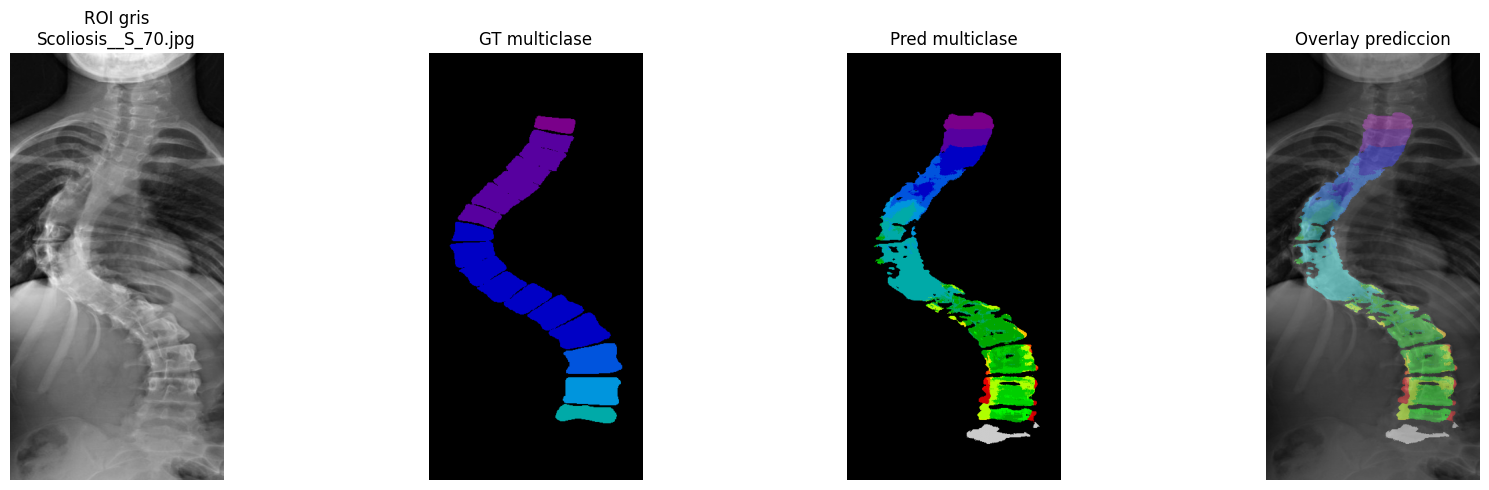

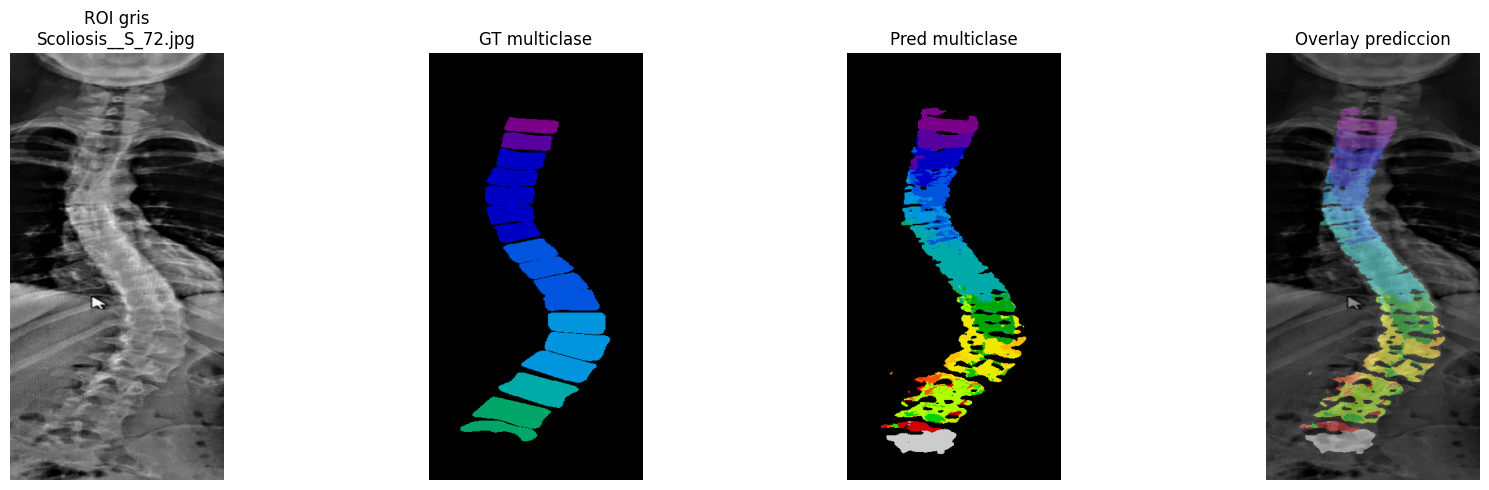

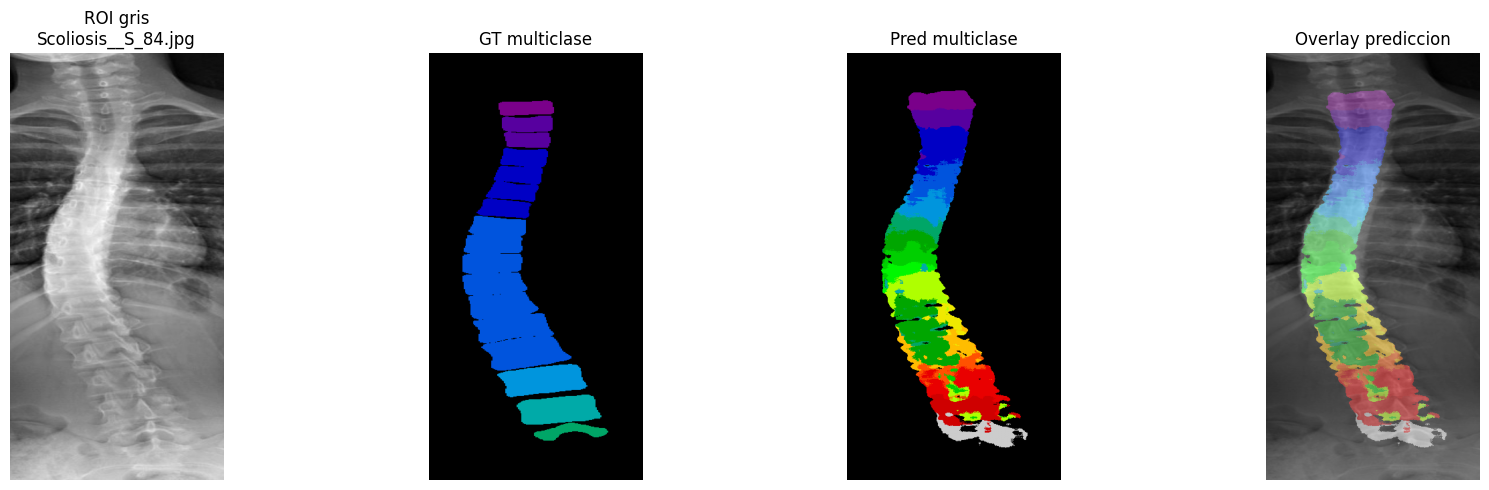

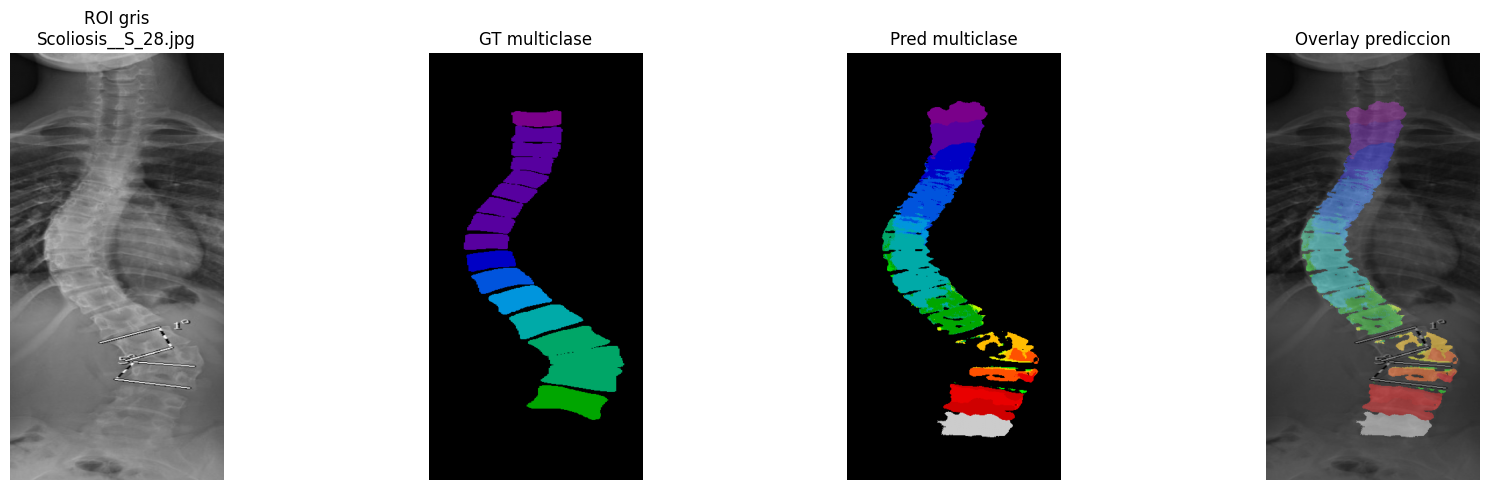

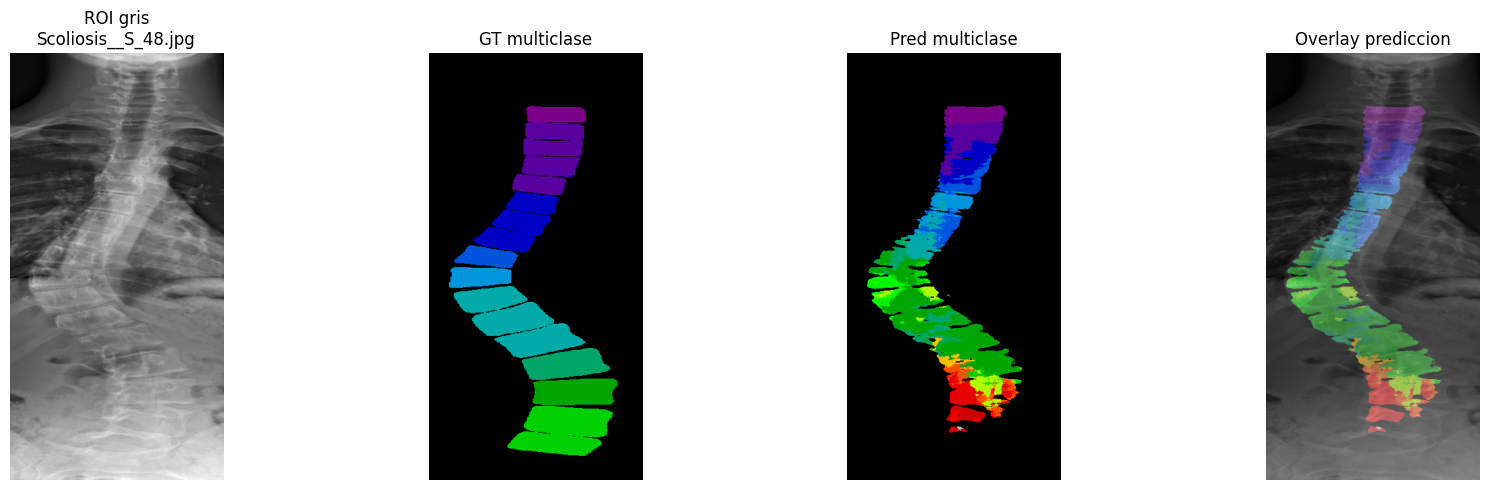

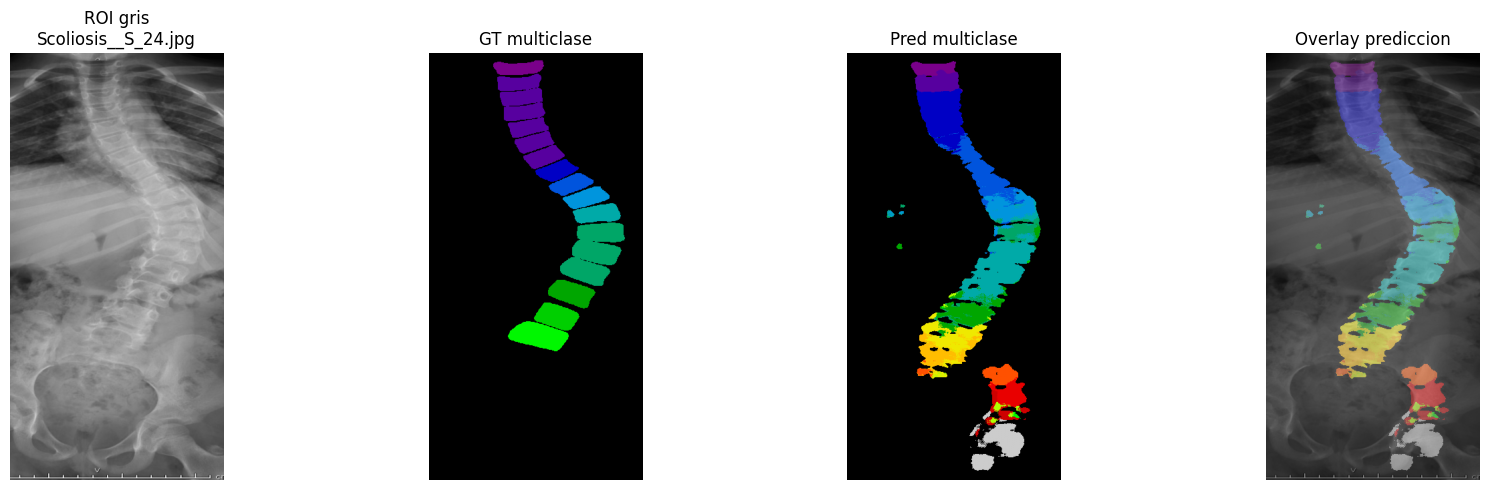

In [11]:
def colorize_mask(mask_2d: np.ndarray, vmax: int) -> np.ndarray:
    mask_for_plot = mask_2d.copy()
    mask_for_plot[mask_for_plot == IGNORE_INDEX] = 0
    return mask_for_plot


def show_sample_prediction(sample_id: str) -> None:
    image_gray = image_crop_lookup[sample_id]
    pred_mask = predicted_masks_small[sample_id]
    target_mask = target_masks_small[sample_id].copy()
    target_mask[target_mask == IGNORE_INDEX] = 0

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(image_gray, cmap='gray')
    axes[0].set_title(f'ROI gris\n{sample_id}')
    axes[1].imshow(target_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[1].set_title('GT multiclase')
    axes[2].imshow(pred_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[2].set_title('Pred multiclase')
    axes[3].imshow(image_gray, cmap='gray')
    axes[3].imshow(pred_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1, alpha=0.45)
    axes[3].set_title('Overlay prediccion')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


sample_ids_to_show = sample_prediction_df.sort_values(
    ['num_missing_labels', 'num_extra_labels', 'num_gt_labels'],
    ascending=[False, False, False],
)['unique_sample_id'].head(N_VIS_SAMPLES).tolist()

print('Muestras seleccionadas para visualizacion:', sample_ids_to_show)
for sample_id in sample_ids_to_show:
    show_sample_prediction(sample_id)

## 11. Resumen final y exportacion

Esta ultima celda exporta tablas utiles para el documento del proyecto:

- metricas globales
- metricas por clase
- predicciones por muestra
- componentes conectados
- chequeo de orden anatomico

In [12]:
global_metrics_path = OUTPUT_DIR / 'inference_global_metrics.csv'
per_class_path = OUTPUT_DIR / 'inference_per_class_metrics.csv'
per_sample_path = OUTPUT_DIR / 'inference_per_sample_summary.csv'
components_path = OUTPUT_DIR / 'inference_connected_components.csv'
centroid_order_path = OUTPUT_DIR / 'inference_centroid_order_report.csv'

global_metrics_df.to_csv(global_metrics_path, index=False)
per_class_df.to_csv(per_class_path, index=False)
sample_prediction_df.to_csv(per_sample_path, index=False)
components_df.to_csv(components_path, index=False)
centroid_order_df.to_csv(centroid_order_path, index=False)

experiment_summary_df = pd.DataFrame([
    {'metric': 'target_subset', 'value': TARGET_SUBSET},
    {'metric': 'test_samples', 'value': int(len(analysis_df))},
    {'metric': 'test_macro_dice_fg', 'value': float(global_metrics_df.loc[global_metrics_df['metric'] == 'test_macro_dice_fg', 'value'].iloc[0])},
    {'metric': 'test_macro_iou_fg', 'value': float(global_metrics_df.loc[global_metrics_df['metric'] == 'test_macro_iou_fg', 'value'].iloc[0])},
    {'metric': 'test_macro_dice_thoracic', 'value': float(global_metrics_df.loc[global_metrics_df['metric'] == 'test_macro_dice_thoracic', 'value'].iloc[0])},
    {'metric': 'test_macro_dice_lumbar', 'value': float(global_metrics_df.loc[global_metrics_df['metric'] == 'test_macro_dice_lumbar', 'value'].iloc[0])},
    {'metric': 'samples_with_non_monotonic_centroid_order', 'value': int((~centroid_order_df['centroid_order_monotonic_y']).sum())},
])
experiment_summary_path = OUTPUT_DIR / 'inference_experiment_summary.csv'
experiment_summary_df.to_csv(experiment_summary_path, index=False)

display(experiment_summary_df)
print('Guardado:', global_metrics_path)
print('Guardado:', per_class_path)
print('Guardado:', per_sample_path)
print('Guardado:', components_path)
print('Guardado:', centroid_order_path)
print('Guardado:', experiment_summary_path)

,metric,value
0,target_subset,partial
1,test_samples,45
2,test_macro_dice_fg,0.339891
3,test_macro_iou_fg,0.213441
4,test_macro_dice_thoracic,0.306984
5,test_macro_dice_lumbar,0.418868
6,samples_with_non_monotonic_centroid_order,26


Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/thoracolumbar_inference_analysis_explained_tuned/inference_global_metrics.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/thoracolumbar_inference_analysis_explained_tuned/inference_per_class_metrics.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/thoracolumbar_inference_analysis_explained_tuned/inference_per_sample_summary.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/thoracolumbar_inference_analysis_explained_tuned/inference_connected_components.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/thoracolumbar_inference_analysis_explained_tuned/inference_centroid_order_report.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentat